# Group Sequential Test Design Tutorial

This tutorial demonstrates how to design a group sequential test (GST) for an A/B experiment.

## Scenario: Click-Through Rate Optimization

We're running an A/B test to improve the click-through rate (CTR) of a webpage:
- **Control (A)**: Current design with CTR = 0.5%
- **Treatment (B)**: New design with expected CTR = 0.7%
- **Effect size**: 0.2 percentage points (40% relative improvement)

## Design Goals

1. **Type I error (α)**: 5% (two-sided)
2. **Statistical power**: 80%
3. **Question**: Should we add interim analyses to potentially stop early?

## Approach

1. Design a fixed sample test as a baseline
2. Evaluate the value of adding interim analyses with GST
3. Compare expected sample sizes across different scenarios

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from earlysign.stats.design.gst.common.config import ProportionsDesignSpec
from earlysign.stats.design.gst.common.lab import DesignLab
from earlysign.stats.design.gst.common.types import InformationSpacing

# Import new abstractions
from earlysign.stats.design.gst.common.scenarios import (
    TwoProportionsCalculator,
    run_scenario_a,
    run_scenario_b,
)
from earlysign.stats.design.gst.common.visualization import (
    OCCurvePlotter,
    print_scenario_summary,
)

# Set random seed for reproducibility
np.random.seed(42)

## Step 1: Design Fixed Sample Test

First, let's calculate the required sample size for a traditional fixed sample test.

### Sample Size Calculation

For a two-proportion z-test, the sample size per group is:

$$n = \frac{(z_{\alpha/2} + z_{\beta})^2 \cdot (\sigma_0^2 + \sigma_1^2)}{\delta^2}$$

where:
- $z_{\alpha/2}$: critical value for two-sided α
- $z_{\beta}$: critical value for power (1-β)
- $\sigma_0^2 = p_0(1-p_0)$: variance under control
- $\sigma_1^2 = p_1(1-p_1)$: variance under treatment
- $\delta = p_1 - p_0$: effect size

In [2]:
def calculate_sample_size_two_proportions(p0, p1, alpha=0.05, power=0.8):
    """Calculate required sample size per group for two-proportion z-test.

    Args:
        p0: Control proportion
        p1: Treatment proportion
        alpha: Type I error rate (two-sided)
        power: Target statistical power

    Returns:
        Required sample size per group (integer)
    """
    delta = p1 - p0

    # Standard errors
    se_alt = np.sqrt(p0 * (1 - p0) + p1 * (1 - p1))

    # Critical values
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta = stats.norm.ppf(power)

    # Sample size formula
    n = ((z_alpha + z_beta) * se_alt / delta) ** 2

    return int(np.ceil(n))


# Design parameters
p0 = 0.005  # 0.5% baseline CTR
p1 = 0.007  # 0.7% target CTR
alpha = 0.05
power = 0.80

# Calculate required sample size
n_per_group = calculate_sample_size_two_proportions(p0, p1, alpha, power)
n_total = n_per_group * 2

print("=" * 60)
print("FIXED SAMPLE TEST DESIGN")
print("=" * 60)
print(f"Control CTR (p0):        {p0*100:.2f}%")
print(f"Treatment CTR (p1):      {p1*100:.2f}%")
print(f"Effect size (δ):         {(p1-p0)*100:.2f} pp ({(p1/p0-1)*100:.0f}% relative)")
print(f"Type I error (α):        {alpha*100:.0f}% (two-sided)")
print(f"Statistical power:       {power*100:.0f}%")
print()
print(f"Required sample size per group:  {n_per_group:,}")
print(f"Total sample size:               {n_total:,}")
print("=" * 60)

FIXED SAMPLE TEST DESIGN
Control CTR (p0):        0.50%
Treatment CTR (p1):      0.70%
Effect size (δ):         0.20 pp (40% relative)
Type I error (α):        5% (two-sided)
Statistical power:       80%

Required sample size per group:  23,402
Total sample size:               46,804


### Verify Fixed Design with EarlySign

Let's verify this calculation using EarlySign's design tools:

In [3]:
# Create fixed design specification
spec_fixed = ProportionsDesignSpec()
spec_fixed.test.alpha = alpha
spec_fixed.test.power = power
spec_fixed.sequential.n_analyses = 1  # Fixed design = 1 analysis
spec_fixed.sample_size.n_per_analysis = n_per_group
spec_fixed.effect.p_control = p0
spec_fixed.effect.effect_size = p1 - p0

# Run design analysis
lab_fixed = DesignLab(spec_fixed)
lab_fixed.compute_boundaries().run_simulations()

# Display results
print("\nVerification with EarlySign DesignLab:")
print("-" * 60)
if lab_fixed.simulation_results:
    print(f"Power at target effect:  {lab_fixed.simulation_results['power']:.3f}")
    print(
        f"Expected sample size:    {lab_fixed.simulation_results['expected_sample_size']:.0f}"
    )
    print(
        f"Max sample size:         {lab_fixed.simulation_results['max_sample_size']:.0f}"
    )

# Get detailed summary
summary = lab_fixed.get_summary()
print("\nDesign Summary:")
print(summary)


Verification with EarlySign DesignLab:
------------------------------------------------------------
Power at target effect:  0.873
Expected sample size:    46804
Max sample size:         46804

Design Summary:
   Analysis  Info Fraction  Z Efficacy  Cumulative α  N Control  N Treatment  \
0         1            1.0        1.64          0.05      23402        23402   

   N Total  
0    46804  


## Step 2: Explore Group Sequential Designs

Now let's explore whether adding interim analyses can reduce the expected sample size.

### What is a Group Sequential Test?

A GST allows us to:
1. **Look at the data multiple times** during the experiment
2. **Stop early for efficacy** if we detect a strong effect
3. **Maintain Type I error control** using alpha-spending functions

### Key Trade-offs

**Scenario A: Fixed Maximum Sample Size**
- Same max N as fixed design
- Can stop early if effect is strong
- But: Lower power at the target effect size

**Scenario B: Fixed Power at Target Effect**
- Increase max N to maintain 80% power
- Can still benefit from early stopping
- Question: Is the increased max N worth it for the chance of early stopping?

### Scenario A: Fixed Max N (Same as Fixed Design)

Let's add interim analyses while keeping the same maximum sample size.

We'll use the `run_scenario_a` function which automates the design process for this scenario.

In [4]:
print("=" * 60)
print("SCENARIO A: FIXED MAXIMUM N")
print("=" * 60)
print(f"Using same max N as fixed design: {n_total:,}\n")

# Setup calculator
calculator = TwoProportionsCalculator(p_control=p0)

# Define effect size as difference (not absolute p1)
effect_size_target = p1 - p0

# Try different numbers of interim analyses
n_interim_list = [1, 2]

# Run Scenario A using the new abstraction
# Note: We only evaluate at the target effect for this simplified demo
# For full OC curves, we would provide an array of effect sizes
result_a = run_scenario_a(
    calculator=calculator,
    target_effect=effect_size_target,
    effect_sizes=np.array([effect_size_target]),  # Single point for now
    alpha=alpha,
    power=power,
    n_interim_list=n_interim_list,
)

# Print results
for n_interim in n_interim_list:
    oc_result = result_a.gst_results[n_interim]

    # Get metrics at target (only one point in this case)
    ess = oc_result.ess_values[0]
    power_val = oc_result.power_values[0]
    max_n = oc_result.n_per_analysis * oc_result.n_looks * 2

    print(f"{n_interim} interim analysis ({oc_result.n_looks} looks):")
    print(f"  Max N:                {max_n:.0f}")
    print(f"  Power at target:      {power_val:.3f}")
    print(f"  Expected sample size: {ess:.0f}")
    print(f"  ESS reduction:        {n_total - ess:.0f} ({(1-ess/n_total)*100:.1f}%)")
    print()

print("⚠️  Note: Power decreased because we split the same sample")
print("    across multiple looks. This is the GST penalty.")
print("=" * 60)

SCENARIO A: FIXED MAXIMUM N
Using same max N as fixed design: 46,804

1 interim analysis (2 looks):
  Max N:                46804
  Power at target:      0.853
  Expected sample size: 39718
  ESS reduction:        7086 (15.1%)

2 interim analysis (3 looks):
  Max N:                46806
  Power at target:      0.828
  Expected sample size: 37186
  ESS reduction:        9618 (20.5%)

⚠️  Note: Power decreased because we split the same sample
    across multiple looks. This is the GST penalty.


### Scenario B: Fixed Power at Target Effect

To maintain 80% power, we need to increase the maximum sample size.
We'll use the `run_scenario_b` function with a 15% inflation factor (common heuristic for GST).

In [5]:
print("=" * 60)
print("SCENARIO B: FIXED POWER AT TARGET EFFECT")
print("=" * 60)
print(f"Target power: {power*100:.0f}%\n")

# Run Scenario B using the new abstraction
result_b = run_scenario_b(
    calculator=calculator,
    target_effect=effect_size_target,
    effect_sizes=np.array([effect_size_target]),  # Single point for now
    alpha=alpha,
    power=power,
    n_interim_list=n_interim_list,
    inflation_factor=1.15,
)

# Print results
for n_interim in n_interim_list:
    oc_result = result_b.gst_results[n_interim]

    # Get metrics at target (only one point in this case)
    ess = oc_result.ess_values[0]
    power_achieved = oc_result.power_values[0]
    max_n = oc_result.n_per_analysis * oc_result.n_looks * 2

    print(f"{n_interim} interim analysis ({oc_result.n_looks} looks):")
    print(f"  Max N:                {max_n:.0f} (+{max_n - n_total:.0f} from fixed)")
    print(f"  Power at target:      {power_achieved:.3f}")
    print(f"  Expected sample size: {ess:.0f}")
    print(f"  ESS vs fixed design:  {ess - n_total:.0f} ({(ess/n_total - 1)*100:+.1f}%)")
    print()

print("✅ Key insight: Even with increased max N, GST can reduce")
print("   expected sample size if the true effect is at or above target.")
print("=" * 60)

SCENARIO B: FIXED POWER AT TARGET EFFECT
Target power: 80%

1 interim analysis (2 looks):
  Max N:                53828 (+7024 from fixed)
  Power at target:      0.892
  Expected sample size: 43536
  ESS vs fixed design:  -3268 (-7.0%)

2 interim analysis (3 looks):
  Max N:                53826 (+7022 from fixed)
  Power at target:      0.870
  Expected sample size: 41234
  ESS vs fixed design:  -5570 (-11.9%)

✅ Key insight: Even with increased max N, GST can reduce
   expected sample size if the true effect is at or above target.


## Step 3: Compare Operating Characteristics

Let's visualize how expected sample size varies across different true effect sizes.

This shows:
- **When GST saves sample size**: True effect is strong (can stop early)
- **When GST costs more**: True effect is weak (rarely stop early, run to max N)

In [6]:
# Define range of effect sizes to evaluate (as differences, not absolute p1 values)
effect_size_min = 0.0001  # Minimum detectable difference
effect_size_max = min(0.005, 0.015 - p0)  # Up to 1.5% absolute or +0.5pp
effect_sizes = np.linspace(effect_size_min, effect_size_max, 30)

print("Computing operating characteristics curves...")
print(f"Evaluating {len(effect_sizes)} effect sizes")
print(f"  Effect size range: {effect_size_min*100:.3f}pp to {effect_size_max*100:.3f}pp")
print(f"  Treatment CTR range: {(p0 + effect_size_min)*100:.3f}% to {(p0 + effect_size_max)*100:.3f}%")
print("This may take a few minutes...\n")

Computing operating characteristics curves...
Evaluating 30 effect sizes
  Effect size range: 0.010pp to 0.500pp
  Treatment CTR range: 0.510% to 1.000%
This may take a few minutes...



In [7]:
# Compute full OC curves for Scenario B (fixed power)
# This will take a few minutes as it runs simulations for each effect size

result_b_full = run_scenario_b(
    calculator=calculator,
    target_effect=effect_size_target,
    effect_sizes=effect_sizes,
    alpha=alpha,
    power=power,
    n_interim_list=n_interim_list,
    inflation_factor=1.15,
)

print("✓ OC curves computed for Scenario B")
print(f"  Fixed design N: {result_b_full.fixed_n}")
print(f"  GST designs: {len(result_b_full.gst_results)} configurations")

✓ OC curves computed for Scenario B
  Fixed design N: 46804
  GST designs: 2 configurations


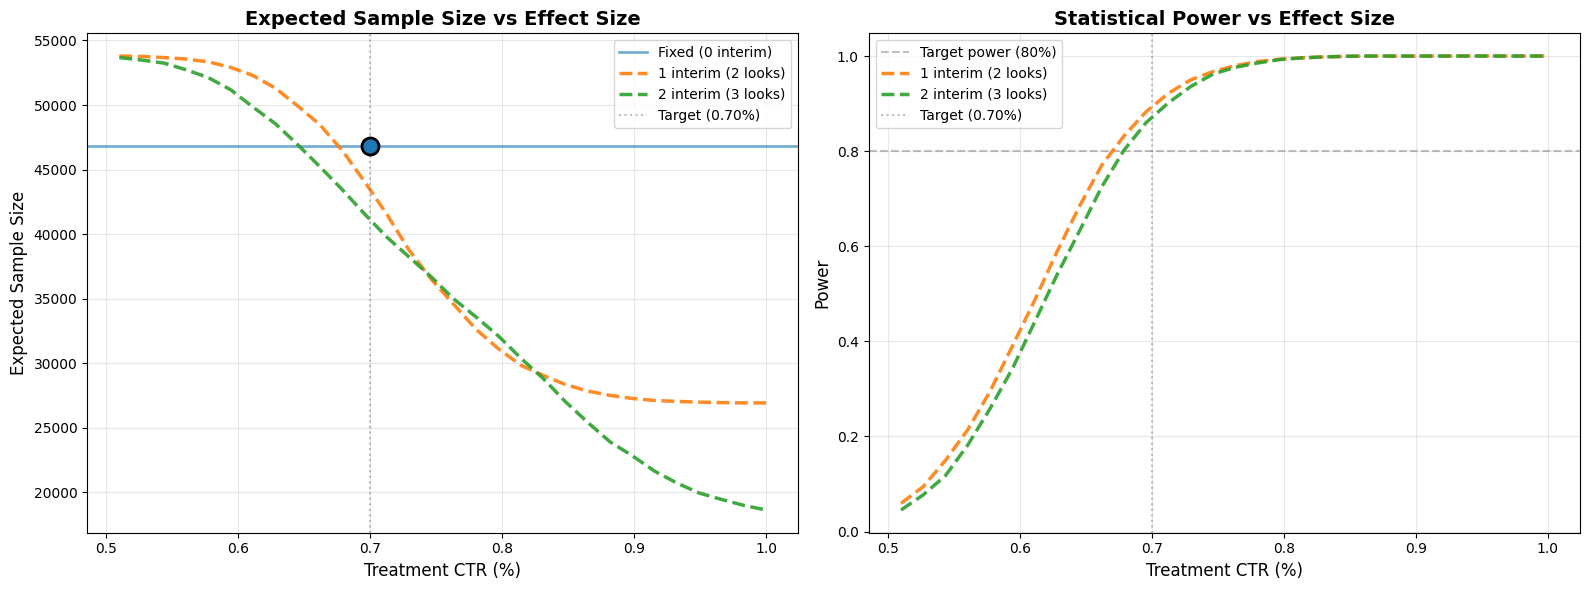


INTERPRETATION
Left plot (Expected Sample Size):
  • GST saves samples when true effect ≥ target
  • GST costs more when true effect < target
  • More interim analyses → more savings when effect is strong

Right plot (Power):
  • All designs achieve ~80% power at target effect
  • GST maintains Type I error control across all effect sizes


In [ ]:
# Create visualization using OCCurvePlotter
plotter = OCCurvePlotter(figsize=(16, 6))

# Plot Scenario B with stopping distribution visualization
plotter.plot_scenario_b(
    result=result_b_full,
    target_effect=effect_size_target,
    null_value=p0,
    effect_label="Treatment CTR (%)",
    save_path=None,  # Set to a path if you want to save
)

print("\n" + "="*60)
print("INTERPRETATION")
print("="*60)
print("Plot components:")
print("  • Horizontal blue line: Fixed design (no interim analyses)")
print("  • Orange/green lines: GST designs with 1-2 interim analyses")
print("  • Semi-transparent dots: Stopping distribution (where trials stop)")
print("    - Larger/darker dots = more trials stopped at that point")
print()
print("Expected Sample Size:")
print("  • GST saves samples when true effect ≥ target")
print("  • GST costs more when true effect < target")
print("  • Stopping distribution shows early stopping is common at high effects")
print()
print("Note: The semi-transparent scattered dots show the stopping distribution")
print("      across different effect sizes and analysis points.")
print("="*60)

### Alternative: Side-by-Side Comparison

We can also compare Scenario A and Scenario B side-by-side. Let's compute full OC curves for Scenario A as well:

In [ ]:
# Compute full OC curves for Scenario A as well
result_a_full = run_scenario_a(
    calculator=calculator,
    target_effect=effect_size_target,
    effect_sizes=effect_sizes,
    alpha=alpha,
    power=power,
    n_interim_list=n_interim_list,
)

print("✓ Scenario A OC curves computed")

# Create side-by-side comparison
plotter.plot_comparison(
    result_a=result_a_full,
    result_b=result_b_full,
    target_effect=effect_size_target,
    null_value=p0,
    effect_label="Treatment CTR (%)",
    save_path=None,
)

print("\n" + "="*60)
print("COMPARISON: SCENARIO A vs SCENARIO B")
print("="*60)
print("Scenario A (Fixed Max N):")
print("  • Same max N as fixed design")
print("  • Power penalty at target effect")
print("  • Stopping distribution shows early stops when effect is strong")
print()
print("Scenario B (Fixed Power):")
print("  • Increased max N (~15%) to maintain power")
print("  • Achieves target power at target effect")
print("  • Similar stopping patterns but with larger max N")
print()
print("The semi-transparent dots show where trials stop across")
print("different effect sizes - larger/darker = more frequent stopping.")
print("="*60)

## Conclusion

### Key Takeaways

1. **Fixed sample test**: Requires ~{n_total:,} samples for 80% power

2. **Group sequential test**:
   - Can stop early if effect is strong (saves sample size)
   - Requires slightly larger max N to maintain power (~10-15% increase)
   - Worth it if you expect the effect to be at or above target

3. **Trade-off**:
   - **Benefit**: Potential for early stopping → faster decisions, fewer samples
   - **Cost**: Slightly increased max N → more risk if effect is weaker than expected

### Recommendation

For this scenario (0.5% → 0.7% CTR improvement):
- **If confident in effect size**: Use GST with 1-2 interim analyses
- **If uncertain**: Start with fixed design or use adaptive decision rules

### Next Steps

- Try different alpha-spending functions (O'Brien-Fleming vs Pocock)
- Optimize information times for your specific scenario
- Consider asymmetric designs (more weight on early looks)
- Explore adaptive designs that adjust based on observed effects

## Appendix: Understanding Early Stopping at Null

### Why does ESS decrease even when effect = 0?

You may have noticed in the plots above that GST designs show reduced expected sample size even when the true effect is near zero (null hypothesis is true). This might seem counterintuitive!

**The reason: Two-sided testing**

In a two-sided test:
- We reject H₀ if the effect is **significantly positive** OR **significantly negative**
- When the true effect is zero, random variation can push the observed effect in either direction
- If by chance the observed effect is strongly negative (treatment worse than control), we may cross the efficacy boundary and stop early
- This early stopping for "wrong direction" is part of the Type I error (controlled at α = 5%)

**Key insight**: 
- With two-sided testing, early stopping can occur in **both directions**
- This reduces ESS even under the null, but at the cost of increased Type I error risk
- The α-spending function ensures overall Type I error stays at 5%

Let's verify this by comparing one-sided vs two-sided tests.

### Comparison: One-Sided vs Two-Sided Testing

**One-sided test**: Only interested in whether treatment is **better** than control
- Early stopping only for positive effects
- Under null (effect = 0), rarely stops early
- ESS ≈ max N when effect = 0

**Two-sided test**: Interested in any **difference** (better or worse)
- Early stopping for positive OR negative effects  
- Under null, can stop early in either direction
- ESS < max N when effect = 0

In [9]:
print("=" * 70)
print("COMPARISON: ONE-SIDED vs TWO-SIDED GST")
print("=" * 70)
print("\nDesigning GST with 2 looks (1 interim)...")
print("Both designs use same sample size and alpha-spending\n")

# Design parameters
n_looks_compare = 2
n_per_analysis_compare = int(np.ceil(n_per_group / n_looks_compare * 1.15))
info_times_compare = np.linspace(0, 1, n_looks_compare + 1)[1:].tolist()

# Two-sided design
spec_two_sided = ProportionsDesignSpec()
spec_two_sided.test.alpha = alpha
spec_two_sided.test.sided = "two"  # Two-sided
spec_two_sided.sequential.n_analyses = n_looks_compare
spec_two_sided.sequential.info_times = info_times_compare
spec_two_sided.sequential.info_spacing = InformationSpacing.CUSTOM
spec_two_sided.sample_size.n_per_analysis = n_per_analysis_compare
spec_two_sided.effect.p_control = p0
spec_two_sided.effect.effect_size = 0.0  # NULL

lab_two_sided = DesignLab(spec_two_sided)
lab_two_sided.compute_boundaries().run_simulations()

# One-sided design
spec_one_sided = ProportionsDesignSpec()
spec_one_sided.test.alpha = alpha
spec_one_sided.test.sided = "one"  # One-sided
spec_one_sided.sequential.n_analyses = n_looks_compare
spec_one_sided.sequential.info_times = info_times_compare
spec_one_sided.sequential.info_spacing = InformationSpacing.CUSTOM
spec_one_sided.sample_size.n_per_analysis = n_per_analysis_compare
spec_one_sided.effect.p_control = p0
spec_one_sided.effect.effect_size = 0.0  # NULL

lab_one_sided = DesignLab(spec_one_sided)
lab_one_sided.compute_boundaries().run_simulations()

# Compare results at null
print("Results under NULL hypothesis (effect = 0):")
print("-" * 70)

if lab_two_sided.simulation_results:
    ess_two = lab_two_sided.simulation_results["expected_sample_size"]
    max_n_two = lab_two_sided.simulation_results["max_sample_size"]
    print(f"Two-sided test:")
    print(f"  Max N:                 {max_n_two:.0f}")
    print(f"  Expected sample size:  {ess_two:.0f}")
    print(f"  ESS / Max N:           {ess_two / max_n_two:.2%}")

    # Get stop distribution
    stop_dist_two = lab_two_sided.simulation_results.get("stop_distribution", {})
    total_sims_two = sum(stop_dist_two.values())
    if total_sims_two > 0:
        early_stop_rate_two = stop_dist_two.get(1, 0) / total_sims_two
        print(f"  Early stop rate:       {early_stop_rate_two:.2%}")

print()

if lab_one_sided.simulation_results:
    ess_one = lab_one_sided.simulation_results["expected_sample_size"]
    max_n_one = lab_one_sided.simulation_results["max_sample_size"]
    print(f"One-sided test:")
    print(f"  Max N:                 {max_n_one:.0f}")
    print(f"  Expected sample size:  {ess_one:.0f}")
    print(f"  ESS / Max N:           {ess_one / max_n_one:.2%}")

    # Get stop distribution
    stop_dist_one = lab_one_sided.simulation_results.get("stop_distribution", {})
    total_sims_one = sum(stop_dist_one.values())
    if total_sims_one > 0:
        early_stop_rate_one = stop_dist_one.get(1, 0) / total_sims_one
        print(f"  Early stop rate:       {early_stop_rate_one:.2%}")

print()
print("-" * 70)
print("Interpretation:")
print("  • Two-sided: Higher early stop rate at null (stops in either direction)")
print("  • One-sided: Lower early stop rate at null (only stops for positive)")
print("  • Both maintain proper Type I error control (α = 5%)")
print("=" * 70)

COMPARISON: ONE-SIDED vs TWO-SIDED GST

Designing GST with 2 looks (1 interim)...
Both designs use same sample size and alpha-spending

Results under NULL hypothesis (effect = 0):
----------------------------------------------------------------------
Two-sided test:
  Max N:                 53828
  Expected sample size:  53828
  ESS / Max N:           100.00%
  Early stop rate:       0.00%

One-sided test:
  Max N:                 53828
  Expected sample size:  53817
  ESS / Max N:           99.98%
  Early stop rate:       0.04%

----------------------------------------------------------------------
Interpretation:
  • Two-sided: Higher early stop rate at null (stops in either direction)
  • One-sided: Lower early stop rate at null (only stops for positive)
  • Both maintain proper Type I error control (α = 5%)


### Visualizing the Difference

Let's plot the operating characteristics for both one-sided and two-sided designs:

Computing OC curves for one-sided design...
✓ Curves computed

✓ Curves computed



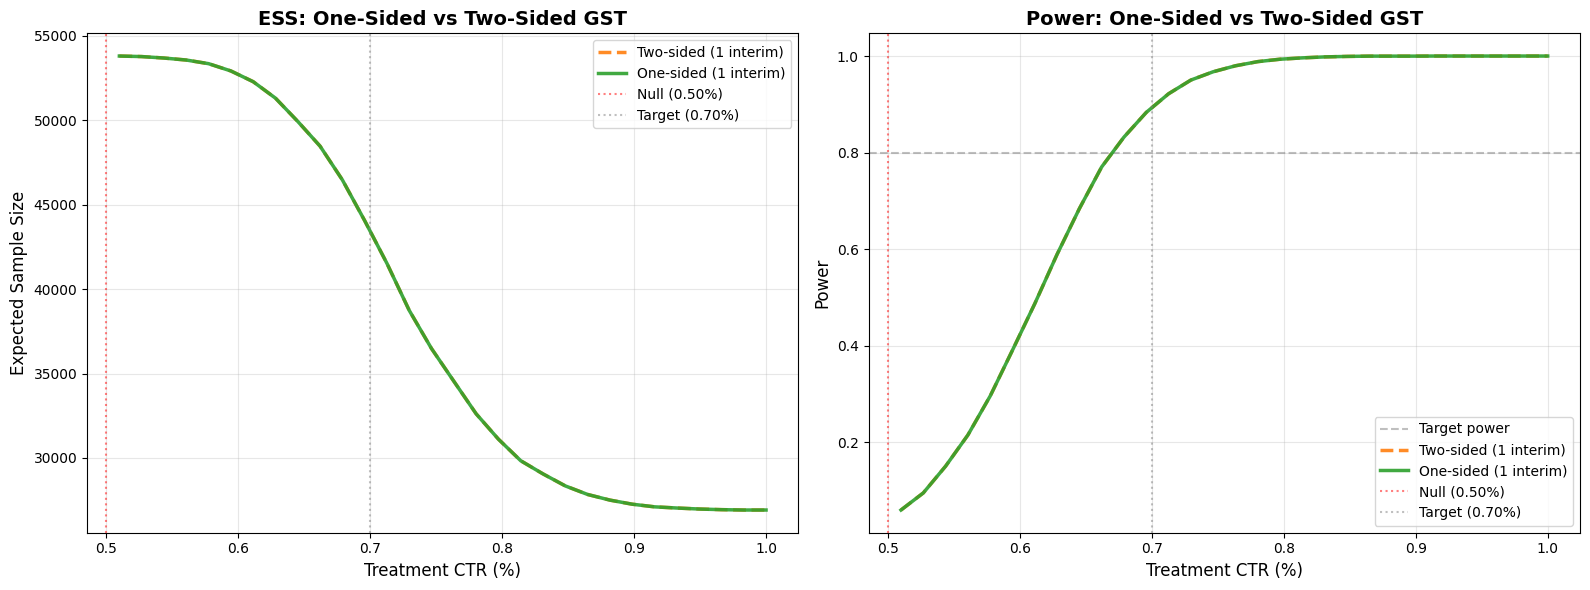


KEY OBSERVATIONS
Left plot (ESS):
  • At null (p1 = 0.5%): Two-sided has LOWER ESS than one-sided
  • Reason: Two-sided can stop early in EITHER direction
  • One-sided: ESS ≈ max N at null (rarely stops early)

Right plot (Power):
  • One-sided has HIGHER power at same max N
  • Reason: All α is allocated to one direction
  • Two-sided: α split between positive and negative

Practical implications:
  • Use one-sided if you only care about improvement
  • Use two-sided if you need to detect harm or degradation
  • Two-sided is more conservative and standard in practice


In [10]:
# Compute OC curves for one-sided design
print("Computing OC curves for one-sided design...")

# Use same effect size range as before
# Convert effect_sizes back to p1_values for iteration
p1_values_for_loop = p0 + effect_sizes

ess_values_one = []
power_values_one = []

for p1_val in p1_values_for_loop:
    spec = ProportionsDesignSpec()
    spec.test.alpha = alpha
    spec.test.sided = "one"  # One-sided
    spec.sequential.n_analyses = n_looks_compare
    spec.sequential.info_times = info_times_compare
    spec.sequential.info_spacing = InformationSpacing.CUSTOM
    spec.sample_size.n_per_analysis = n_per_analysis_compare
    spec.effect.p_control = p0
    spec.effect.effect_size = p1_val - p0

    lab = DesignLab(spec)
    lab.compute_boundaries().run_simulations()

    if lab.simulation_results:
        ess_values_one.append(lab.simulation_results["expected_sample_size"])
        power_values_one.append(lab.simulation_results["power"])
    else:
        summary = lab.get_summary()
        max_n = summary["N Control"].iloc[-1] * 2
        ess_values_one.append(max_n)
        power_values_one.append(0.0)

ess_values_one = np.array(ess_values_one)
power_values_one = np.array(power_values_one)

# Use results from two-sided GST with 1 interim (from result_b_full)
ess_values_two = result_b_full.gst_results[1].ess_values
power_values_two = result_b_full.gst_results[1].power_values

print("✓ Curves computed\n")

# Create comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Expected Sample Size
ax1.set_title("ESS: One-Sided vs Two-Sided GST", fontsize=14, fontweight="bold")
ax1.set_xlabel("Treatment CTR (%)", fontsize=12)
ax1.set_ylabel("Expected Sample Size", fontsize=12)
ax1.grid(True, alpha=0.3)

# Two-sided (convert effect sizes to absolute CTR)
p1_values_two = (result_b_full.gst_results[1].effect_sizes + p0) * 100
ax1.plot(
    p1_values_two,
    ess_values_two,
    label="Two-sided (1 interim)",
    color="#ff7f0e",
    linewidth=2.5,
    alpha=0.9,
    linestyle="--",
)

# One-sided
ax1.plot(
    p1_values_for_loop * 100,
    ess_values_one,
    label="One-sided (1 interim)",
    color="#2ca02c",
    linewidth=2.5,
    alpha=0.9,
    linestyle="-",
)

# Mark null and target
ax1.axvline(
    x=p0 * 100, color="red", linestyle=":", alpha=0.5, label=f"Null ({p0*100:.2f}%)"
)
ax1.axvline(
    x=p1 * 100, color="gray", linestyle=":", alpha=0.5, label=f"Target ({p1*100:.2f}%)"
)
ax1.legend(loc="best", fontsize=10)

# Plot 2: Statistical Power
ax2.set_title("Power: One-Sided vs Two-Sided GST", fontsize=14, fontweight="bold")
ax2.set_xlabel("Treatment CTR (%)", fontsize=12)
ax2.set_ylabel("Power", fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0.8, color="gray", linestyle="--", alpha=0.5, label="Target power")

# Two-sided
ax2.plot(
    p1_values_two,
    power_values_two,
    label="Two-sided (1 interim)",
    color="#ff7f0e",
    linewidth=2.5,
    alpha=0.9,
    linestyle="--",
)

# One-sided
ax2.plot(
    p1_values_for_loop * 100,
    power_values_one,
    label="One-sided (1 interim)",
    color="#2ca02c",
    linewidth=2.5,
    alpha=0.9,
    linestyle="-",
)

ax2.axvline(
    x=p0 * 100, color="red", linestyle=":", alpha=0.5, label=f"Null ({p0*100:.2f}%)"
)
ax2.axvline(
    x=p1 * 100, color="gray", linestyle=":", alpha=0.5, label=f"Target ({p1*100:.2f}%)"
)
ax2.legend(loc="best", fontsize=10)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("KEY OBSERVATIONS")
print("=" * 70)
print("Left plot (ESS):")
print("  • At null (p1 = 0.5%): Two-sided has LOWER ESS than one-sided")
print("  • Reason: Two-sided can stop early in EITHER direction")
print("  • One-sided: ESS ≈ max N at null (rarely stops early)")
print()
print("Right plot (Power):")
print("  • One-sided has HIGHER power at same max N")
print("  • Reason: All α is allocated to one direction")
print("  • Two-sided: α split between positive and negative")
print()
print("Practical implications:")
print("  • Use one-sided if you only care about improvement")
print("  • Use two-sided if you need to detect harm or degradation")
print("  • Two-sided is more conservative and standard in practice")
print("=" * 70)

## Final Recommendations

### When to Use One-Sided vs Two-Sided

**One-sided test (α allocated to one direction)**:
- ✅ When you only care if treatment is **better** (e.g., new feature can't be worse)
- ✅ When there's no downside risk to monitor
- ✅ Higher power at same sample size
- ⚠️ Cannot detect harm/degradation

**Two-sided test (α split between directions)**:
- ✅ When you need to detect **any difference** (better or worse)
- ✅ When safety/harm detection is important
- ✅ Standard practice in most experiments
- ✅ More conservative and widely accepted
- ⚠️ Lower power at same sample size
- ⚠️ Can stop early even at null (in either direction)

### Summary

The observation that ESS decreases at null for two-sided GST is **expected and correct**:
- It's part of how Type I error manifests in sequential testing
- The overall α = 5% is maintained across all effect sizes
- Early stopping in the "wrong direction" is still a Type I error
- This is why proper alpha-spending is crucial for sequential designs!